# Pandana: the nearest station at many origins


OSMnx built our graph. Here Pandana reuses it to calculate the nearest of the same three snapped station locations for every graph node.

This is a separate notebook so the core lesson needs no Pandana installation. See `START_HERE.md`.

In [1]:
import osmnx as ox
import geopandas as gpd
import pandana as pdna

In [2]:
G = ox.project_graph(ox.load_graphml("data/walk.graphml"))
nodes, edges = ox.graph_to_gdfs(G)

Keep the shortest parallel edge between a pair of nodes. Pandana then needs node coordinates and an edge table. `twoway=False` means use the directed arcs already in the OSMnx graph.

In [3]:
edges = edges.reset_index().sort_values("length")
edges = edges.drop_duplicates(["u", "v"])
net = pdna.Network(
    nodes.x, nodes.y, edges.u, edges.v,
    edges[["length"]], twoway=False
)

In [4]:
stations = gpd.read_file("data/stations.geojson").to_crs(nodes.crs)
station_ids = ox.nearest_nodes(G, X=stations.geometry.x, Y=stations.geometry.y)
station_points = nodes.loc[station_ids]

Use the snapped station coordinates, just as in the main notebook. We ask only for the nearest station within 1,200 m.

In [5]:
net.set_pois(
    "stations", maxdist=1200, maxitems=1,
    x_col=station_points.x, y_col=station_points.y
)

In [6]:
access = net.nearest_pois(distance=1200, category="stations", num_pois=1)
access.head()

,1
osmid,
109727353,1200.0
109727357,1200.0
110024116,1200.0
109924749,1200.0
109924757,1200.0


Column `1` is distance to the nearest station. Pandana uses the search limit for an unmatched result by default. Values at the limit should not be read as exact measured distances.

<Axes: >

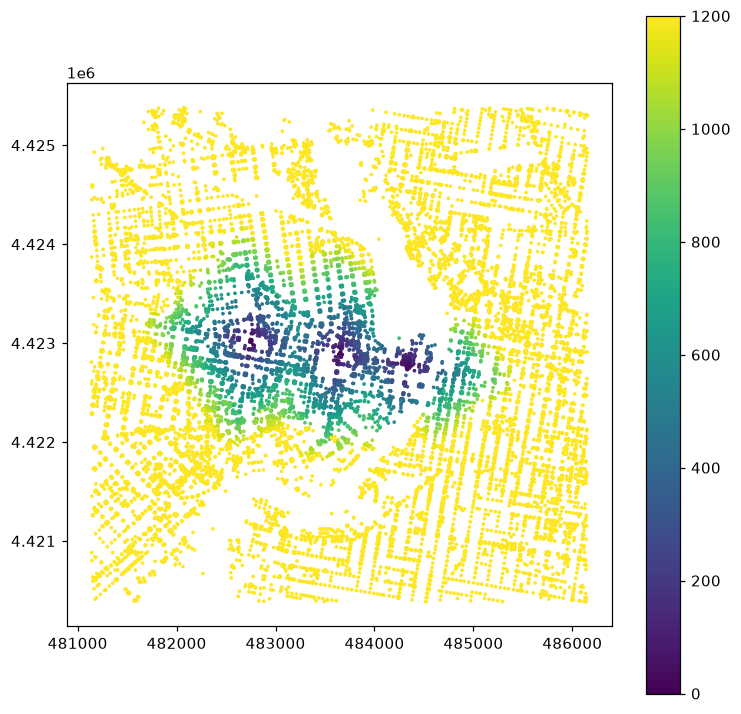

In [7]:
nodes["station_m"] = access[1]
nodes.plot(column="station_m", legend=True, markersize=2, figsize=(8, 8))

**Try changing the question:** what would “third nearest station” measure? You would need to increase both `maxitems` in `set_pois` and `num_pois` in `nearest_pois`.

A faster accessibility engine does not resolve missing entrances, incomplete paths, or population data.

Data © OpenStreetMap contributors, ODbL 1.0. [Pandana API reference](https://udst.github.io/pandana/network.html).